#   Exploratory Analysis — Leakage-Aware Healthcare ML

This notebook performs exploratory analysis for healthcare machine learning experiments focused on:

- data quality inspection
- class imbalance analysis
- missing-value behavior
- feature distributions
- correlation structure
- robustness-oriented preprocessing

The goal is to support leakage-aware and reproducible evaluation workflows.

# Import files

In [15]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Corrected style application using seaborn's set_style
sns.set_style("darkgrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# LOAD DATA

In [5]:
import pandas as pd

# Example dataset loading

df = pd.read_csv("../content/cardio_train.csv", sep=';')

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


#  DATA OVERVIEW

In [10]:
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nDuplicate Rows:", df.duplicated().sum())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None

Missing Values:


,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0



Duplicate Rows: 0


# TARGET DISTRIBUTION

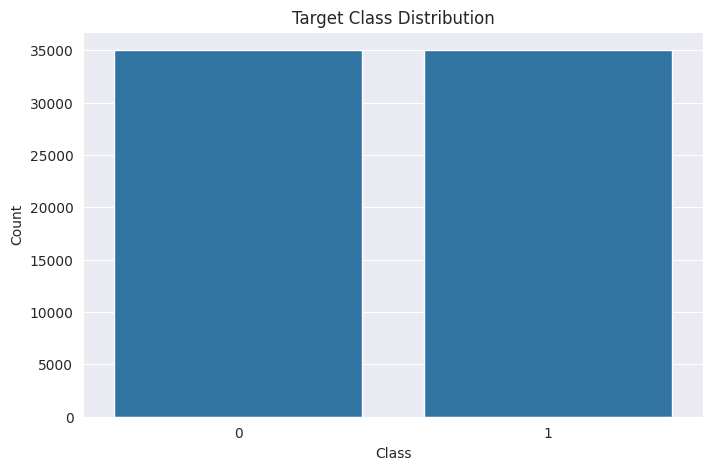

In [18]:
target_column = "cardio"

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x=target_column
)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

# MISSING VALUE VISUALIZATION

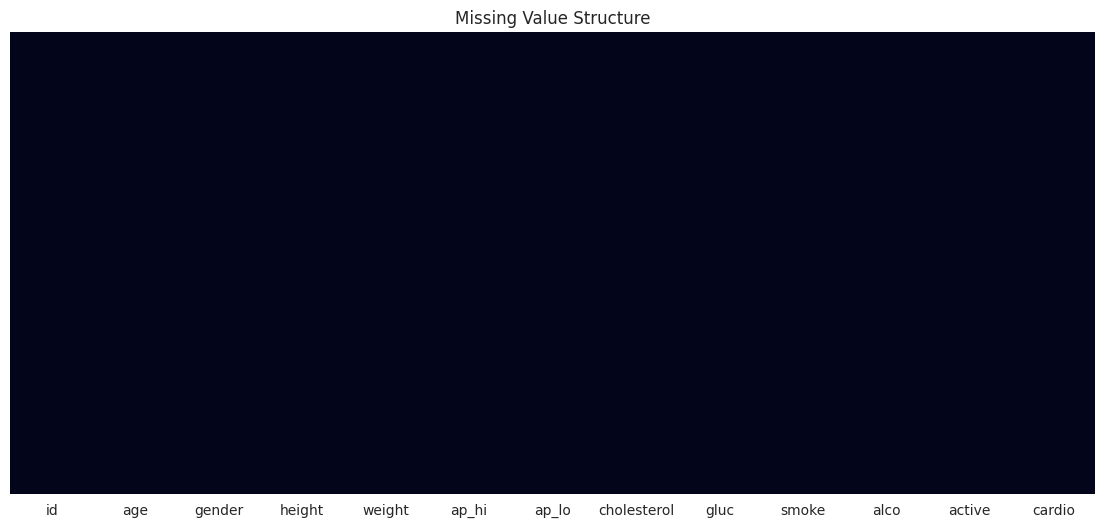

In [19]:
plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Structure")

plt.show()

# FEATURE DISTRIBUTIONS

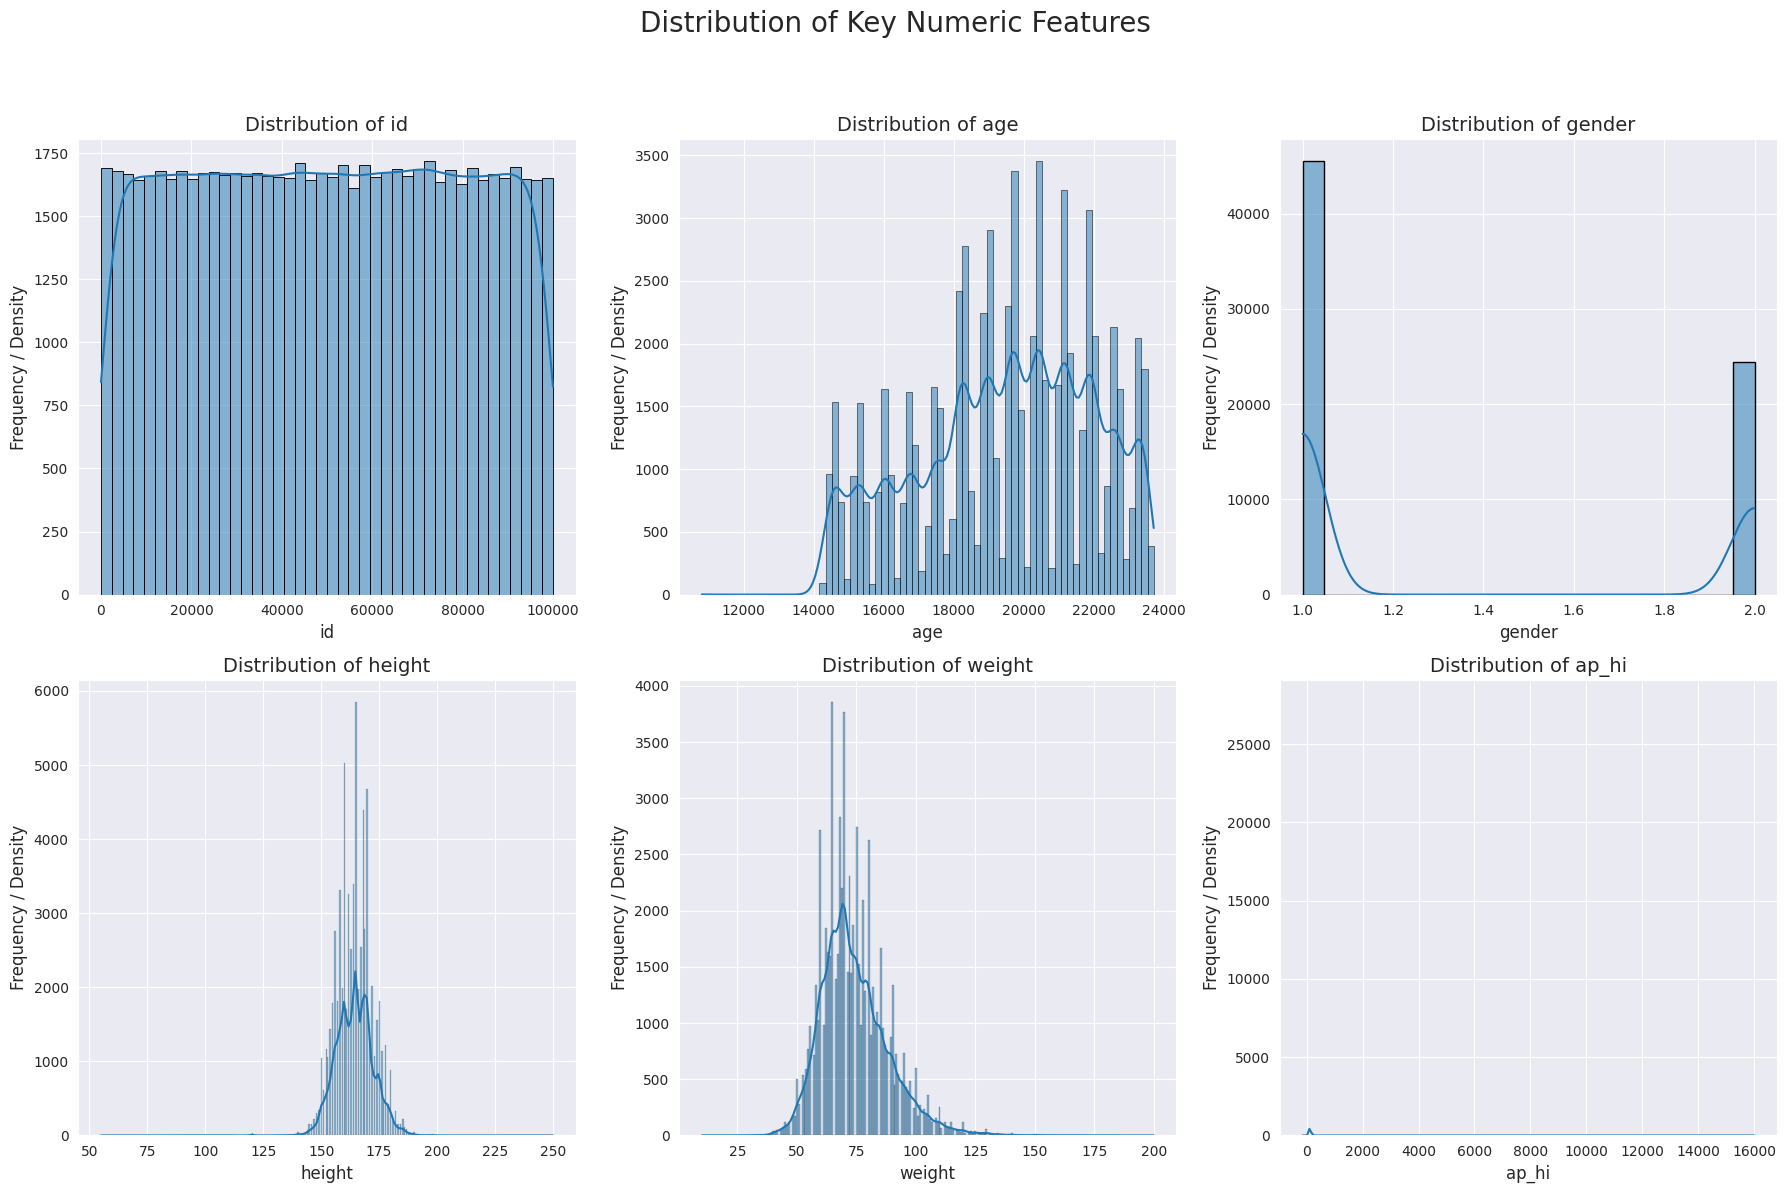

In [20]:
numeric_cols = df.select_dtypes(include=np.number).columns[:6]

fig, axes = plt.subplots(2, 3, figsize=(18,12))
fig.suptitle('Distribution of Key Numeric Features', fontsize=20, y=1.02)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i],
        palette='viridis',
        edgecolor='black'
    )

    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frequency / Density', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle

plt.show()

# CORRELATION ANALYSIS

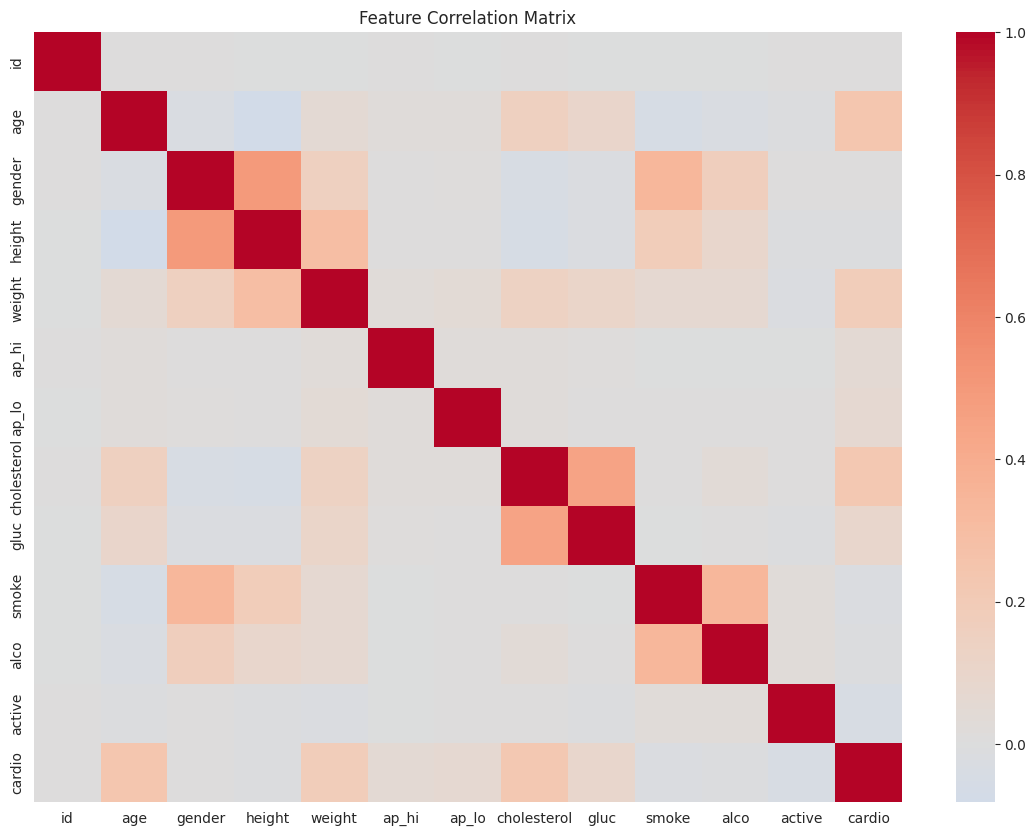

In [21]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

# BASIC PREPROCESSING

In [22]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df = numeric_df.fillna(
    numeric_df.median()
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(numeric_df)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (70000, 13)


# PCA REPRESENTATION

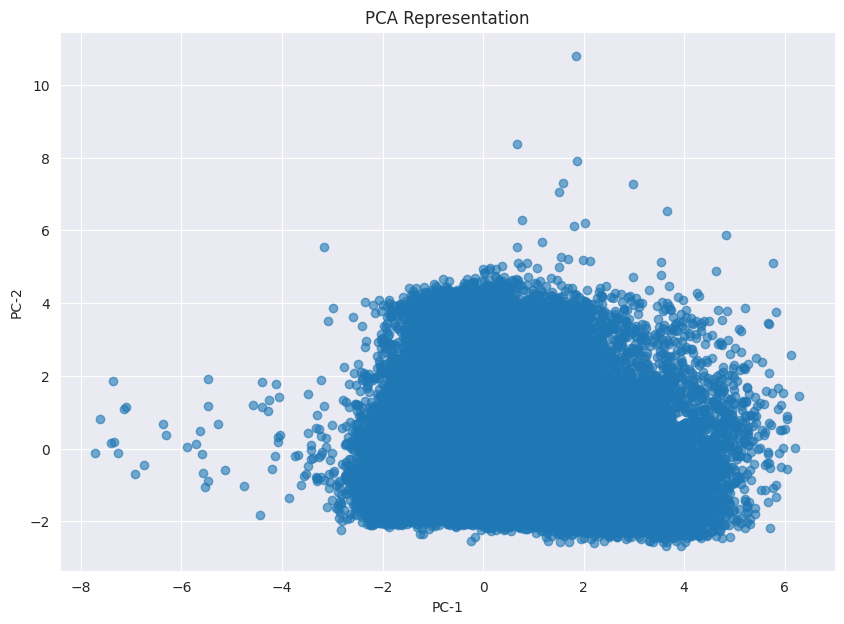

In [23]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.6
)

plt.title("PCA Representation")

plt.xlabel("PC-1")
plt.ylabel("PC-2")

plt.show()

# t-SNE REPRESENTATION

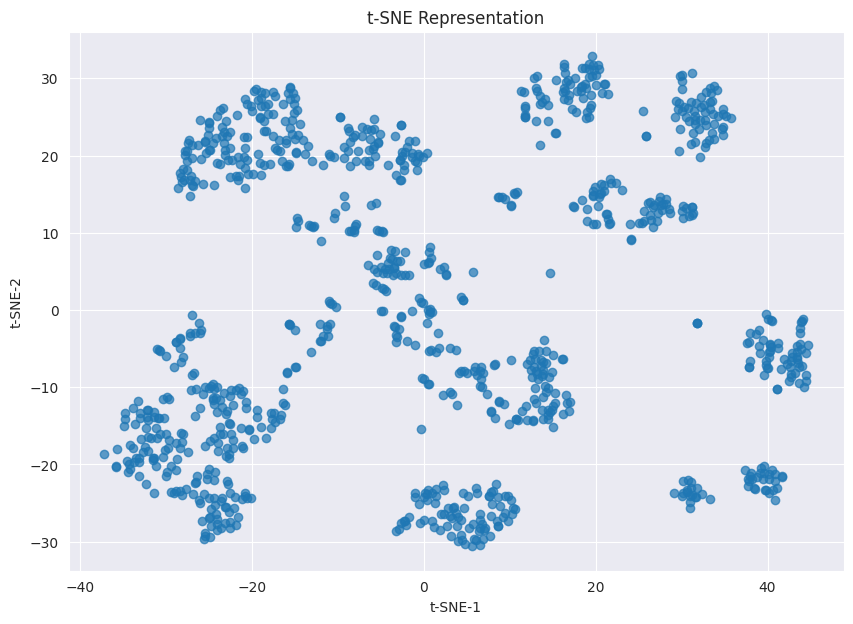

In [24]:
tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_scaled[:1000])

plt.figure(figsize=(10,7))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    alpha=0.7
)

plt.title("t-SNE Representation")

plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")

plt.show()

# Observations

Initial exploratory analysis suggests:

- potential class imbalance
- nonlinear feature relationships
- moderate correlation structure
- possible latent grouping behavior

These findings motivate:
- calibration-aware evaluation
- leakage-safe validation
- robustness-oriented benchmarking
- representation learning analysis